In [1]:
import json, polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"; F = ROOT / "reports" / "figures"
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_tbl_width_chars(200)
def show(p): display(Image(filename=str(p)))
def tab(p, cols=None):
    d = pl.read_csv(p); return d.select(cols) if cols else d

# 02 · Exploratory analysis (development period only)
Each chart answers one question; the holdout (2025-10 → 2026-09) is excluded.

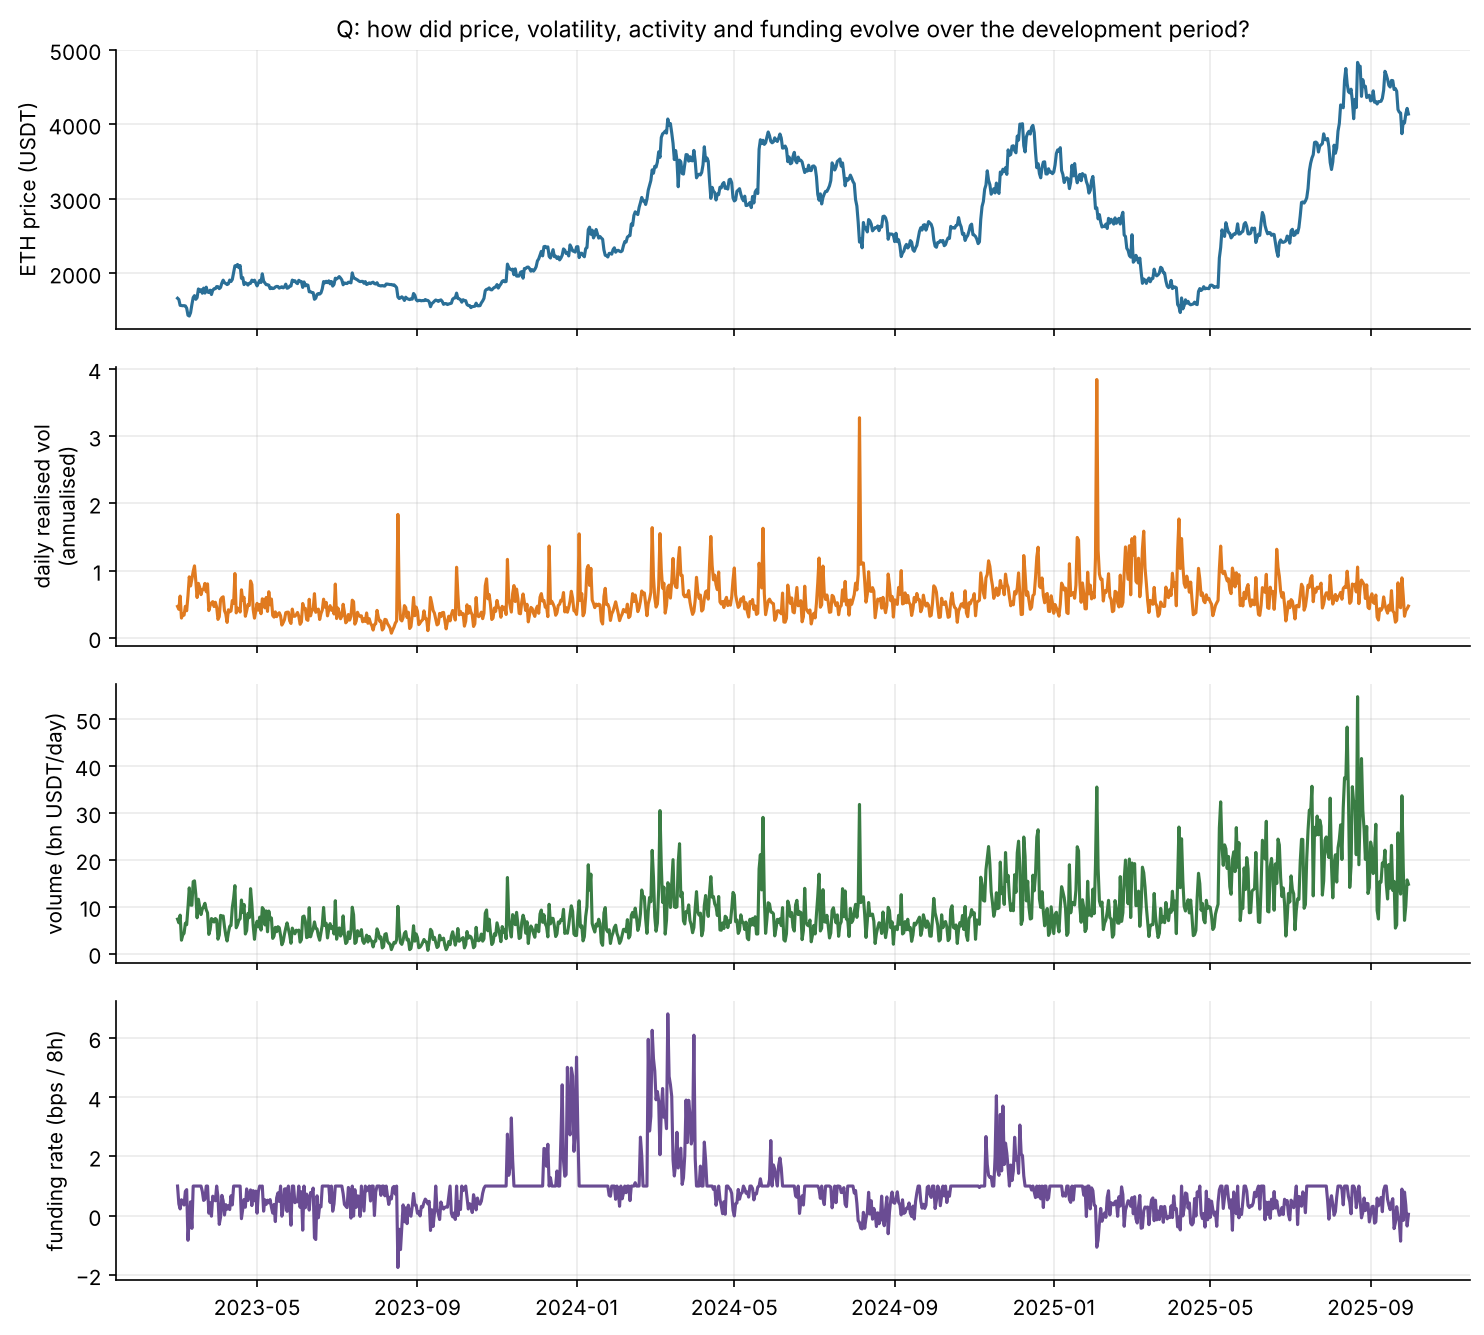

In [2]:
show(F / 'eda/01_price_vol_volume_funding.png')

**Are returns Gaussian?** Heavy tails matter for the choice of tests (HAC, bootstrap) and for risk.

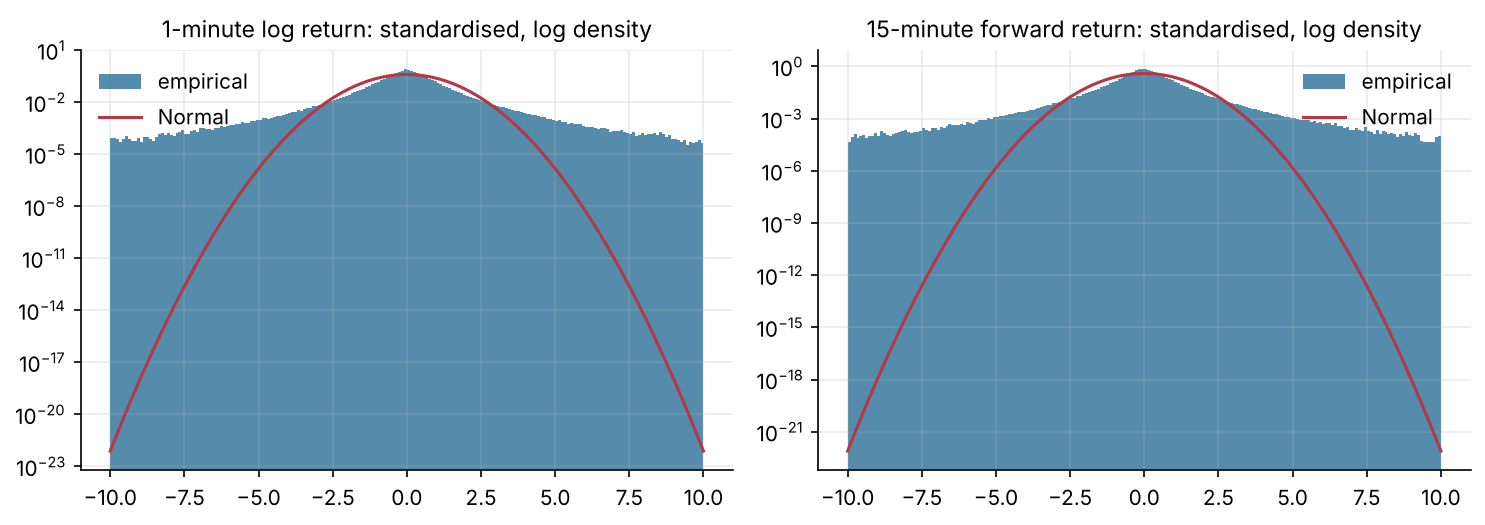

series,n,mean_bps,std_bps,skew,excess_kurtosis,p01_bps,p99_bps,share_zero
str,i64,f64,f64,f64,f64,f64,f64,f64
"""1m log return""",1360739,0.006959,8.924254,-3.016428,487.376779,-23.635524,23.684492,0.012339
"""15m forward return""",1360740,0.158339,32.883307,-0.674027,59.211729,-92.044096,91.861354,0.001139


In [3]:
show(F / 'eda/02_return_tails.png'); tab(T / 'eda_return_distribution.csv')

**Is there linear return autocorrelation? Volatility clustering?**

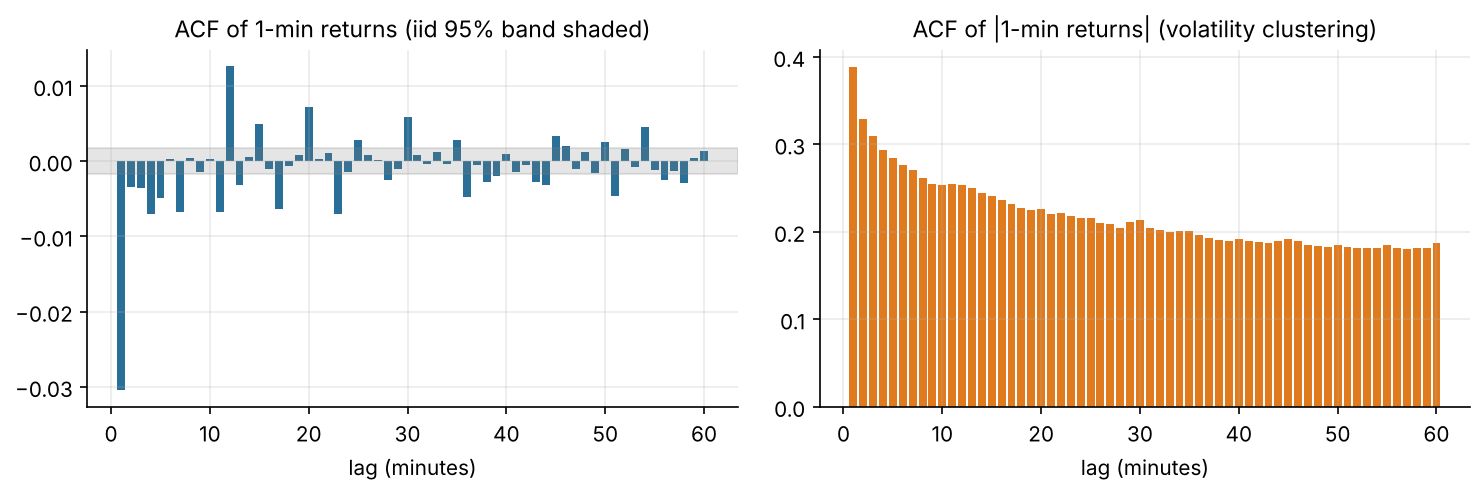

In [4]:
show(F / 'eda/03_autocorrelation.png')

**Intraday seasonality** motivates the hour-of-day features and the trailing 1-day z-scores.

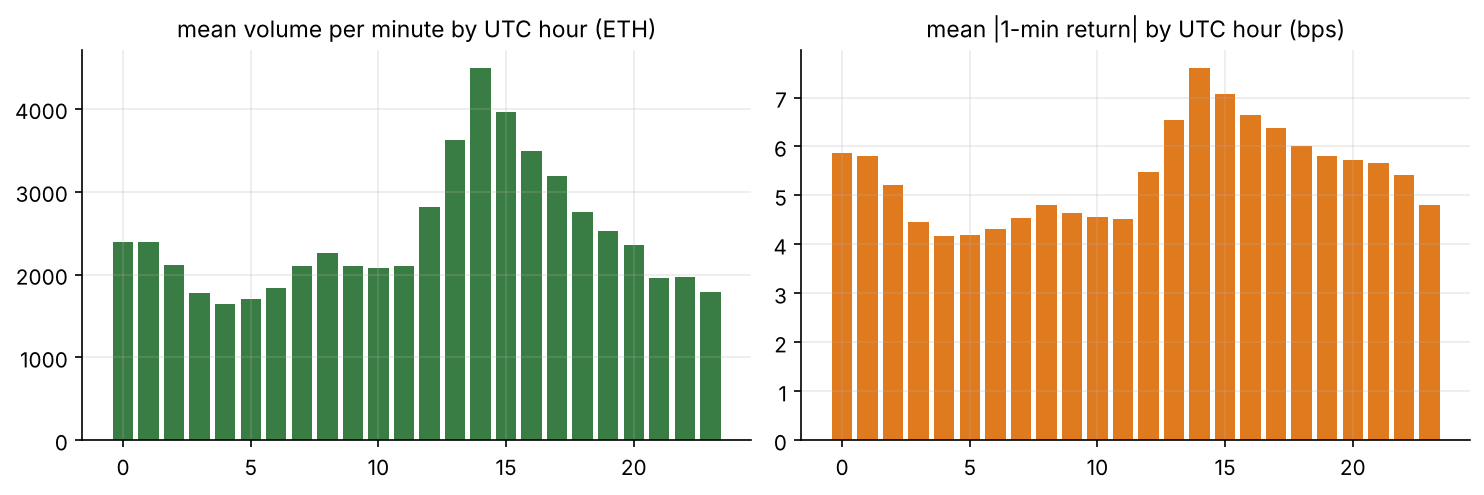

In [5]:
show(F / 'eda/04_intraday_seasonality.png')

**How are order-flow and book imbalances distributed?**

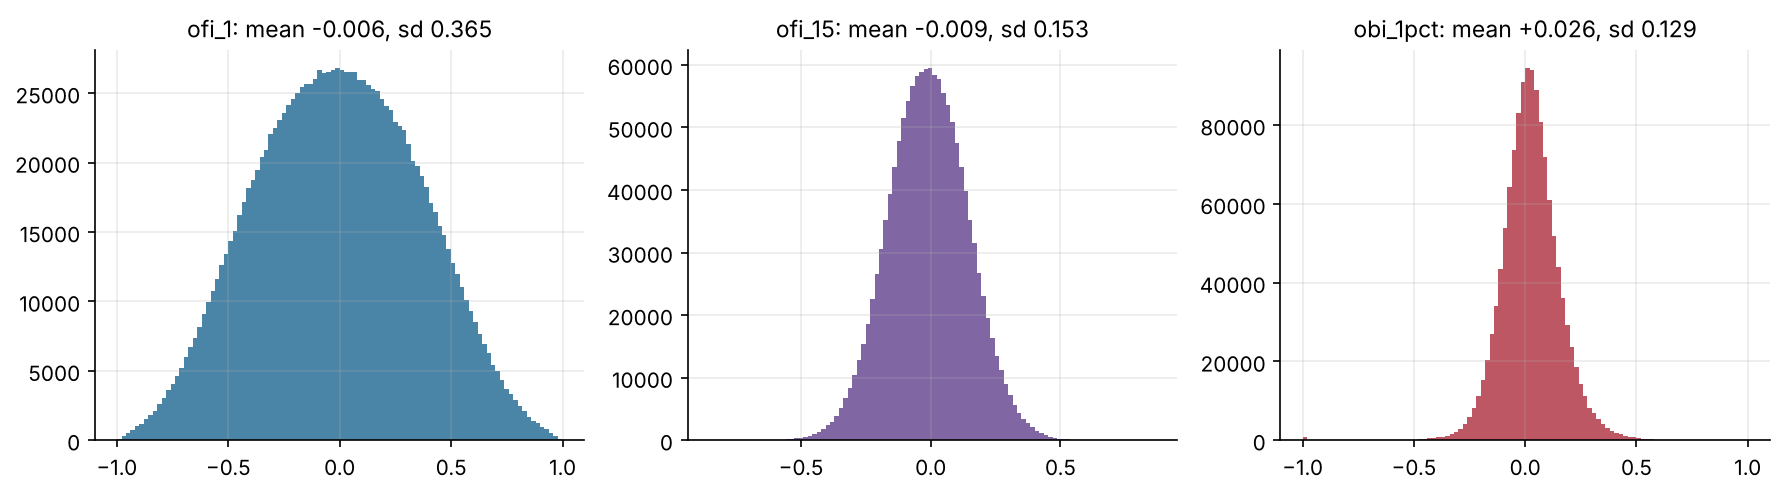

feature,n,mean,sd,p05,p50,p95,acf1
str,i64,f64,f64,f64,f64,f64,f64
"""ofi_1""",1360687,-0.00601,0.364669,-0.602675,-0.006832,0.593538,0.113535
"""ofi_5""",1360721,-0.008364,0.225774,-0.375558,-0.009054,0.361301,0.821867
"""ofi_15""",1360716,-0.008949,0.153115,-0.258063,-0.009841,0.242718,0.943237
"""ofi_60""",1360681,-0.009271,0.08596,-0.148813,-0.009925,0.132313,0.985549
"""trade_imb_15""",1360716,0.000278,0.113429,-0.176102,0.000418,0.174803,0.974139
"""obi_1pct""",1306853,0.025699,0.129021,-0.171717,0.022221,0.238114,0.921272
"""obi_2pct""",1306853,0.051513,0.121836,-0.136324,0.047604,0.254712,0.959201
"""obi_3pct""",1306853,0.064183,0.113719,-0.103266,0.056143,0.266604,0.978394
"""obi_5pct""",1306853,0.095618,0.113239,-0.069491,0.086943,0.302292,0.988901


In [6]:
show(F / 'eda/05_imbalance_distributions.png'); tab(T / 'eda_imbalance_summary.csv')

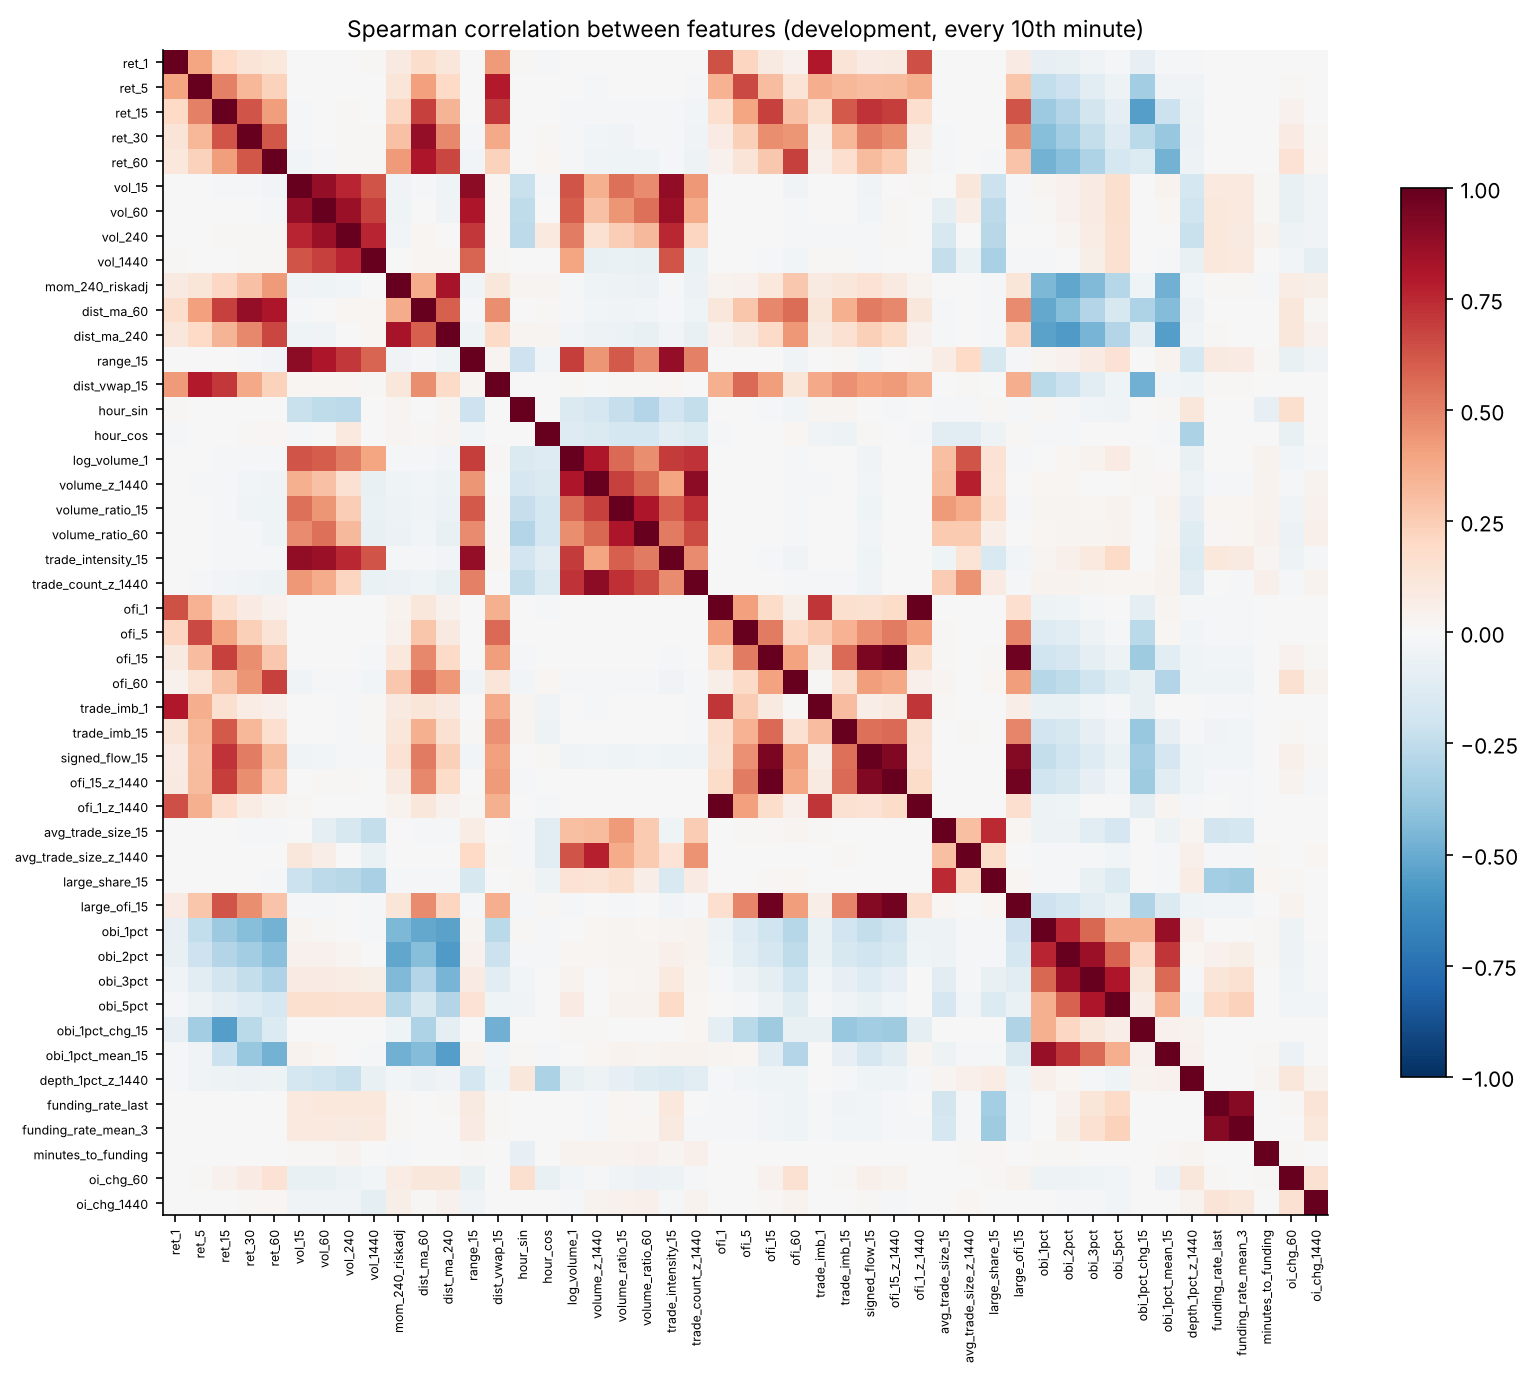

In [7]:
show(F / 'eda/06_feature_correlation.png')

In [8]:
json.loads((T / 'stats_summary.json').read_text())

{'rows_dev': 1360740,
 'corr_ofi1_ret1_contemporaneous': 0.4667951013529146,
 'corr_obi1_ret1_contemporaneous': -0.07337622764792359,
 'n_univariate_tests': 36}